In [17]:
import whisper
import time

In [19]:
# 모델 목록
models = ["tiny", "base", "small"]

# 비교할 오디오 파일 경로
audio_file = "eraser_a.wav"

# 결과 저장
results = {}

# 모델별로 성능 평가
for model_name in models:
    print(f"Evaluating model: {model_name}")
    model = whisper.load_model(model_name)
    
    # 시작 시간 기록
    start_time = time.time()
    
    # 오디오 파일 변환
    result = model.transcribe(
        audio_file,
        language="en",
        task="transcribe",    # 번역 대신 음성을 그대로 텍스트로 변환
        beam_size=10,
        best_of=5,
        temperature=0
    )
    
    # 처리 시간 계산
    elapsed_time = time.time() - start_time
    
    # 결과 저장
    results[model_name] = {
        "transcription": result["text"],
        "processing_time": elapsed_time
    }
    print(f"{model_name} model completed in {elapsed_time:.2f} seconds\n")

# 결과 출력
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"Processing Time: {data['processing_time']:.2f} seconds")
    print(f"Transcription:\n{data['transcription']}\n")

Evaluating model: tiny


/opt/homebrew/Caskroom/miniconda/base/envs/eng/lib/python3.8/site-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp,

tiny model completed in 3.97 seconds

Evaluating model: base


/opt/homebrew/Caskroom/miniconda/base/envs/eng/lib/python3.8/site-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp,

base model completed in 2.18 seconds

Evaluating model: small


/opt/homebrew/Caskroom/miniconda/base/envs/eng/lib/python3.8/site-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp,

small model completed in 5.26 seconds

Model: tiny
Processing Time: 3.97 seconds
Transcription:
 Your Racer.

Model: base
Processing Time: 2.18 seconds
Transcription:
 Eraser

Model: small
Processing Time: 5.26 seconds
Transcription:
 Eraser



In [6]:
import librosa
import soundfile as sf

def resample_audio(input_path, output_path, target_sr=16000):
    # 음성 파일을 로드하고, 대상 샘플링 레이트로 변환ㅌ
    audio, sr = librosa.load(input_path, sr=target_sr)
    # 새 파일로 저장
    sf.write(output_path, audio, target_sr)
    print(f"Audio resampled to {target_sr} Hz and saved to {output_path}")

# 예시 사용
resample_audio("audio.wav", "playground.wav")


Audio resampled to 16000 Hz and saved to playground.wav


In [7]:
import torch
import soundfile as sf
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# 모델과 프로세서 로드
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")



Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# 음성 파일 로드 함수
def load_audio(path):
    speech, rate = sf.read(path)
    if rate != 16000:
        raise ValueError("샘플링 레이트는 16000Hz여야 합니다.")
    return speech

# 음성을 텍스트로 변환하는 함수
def speech_to_text(audio_path):
    speech = load_audio(audio_path)
    inputs = processor(speech, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        logits = model(inputs.input_values).logits
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(predicted_ids)
    return transcription[0]


In [10]:

# 예시 파일로 테스트
audio_file_path = "playground.wav"  # .wav 파일 경로를 입력
transcription = speech_to_text(audio_file_path)
print("Transcription:", transcription)

Transcription: PLAY GROUNDE


In [12]:
from faster_whisper import WhisperModel

model = WhisperModel("deepdml/faster-whisper-large-v3-turbo-ct2")




[2024-11-06 11:21:19.547] [ctranslate2] [thread 7713842] [warning] The compute type inferred from the saved model is float16, but the target device or backend do not support efficient float16 computation. The model weights have been automatically converted to use the float32 compute type instead.


In [14]:
segments, info = model.transcribe("eraser_scale.wav")
for segment in segments:
    print("[%.2fs -> %.2fs] %s" % (segment.start, segment.end, segment.text))

[0.00s -> 2.00s]  이를 있어.


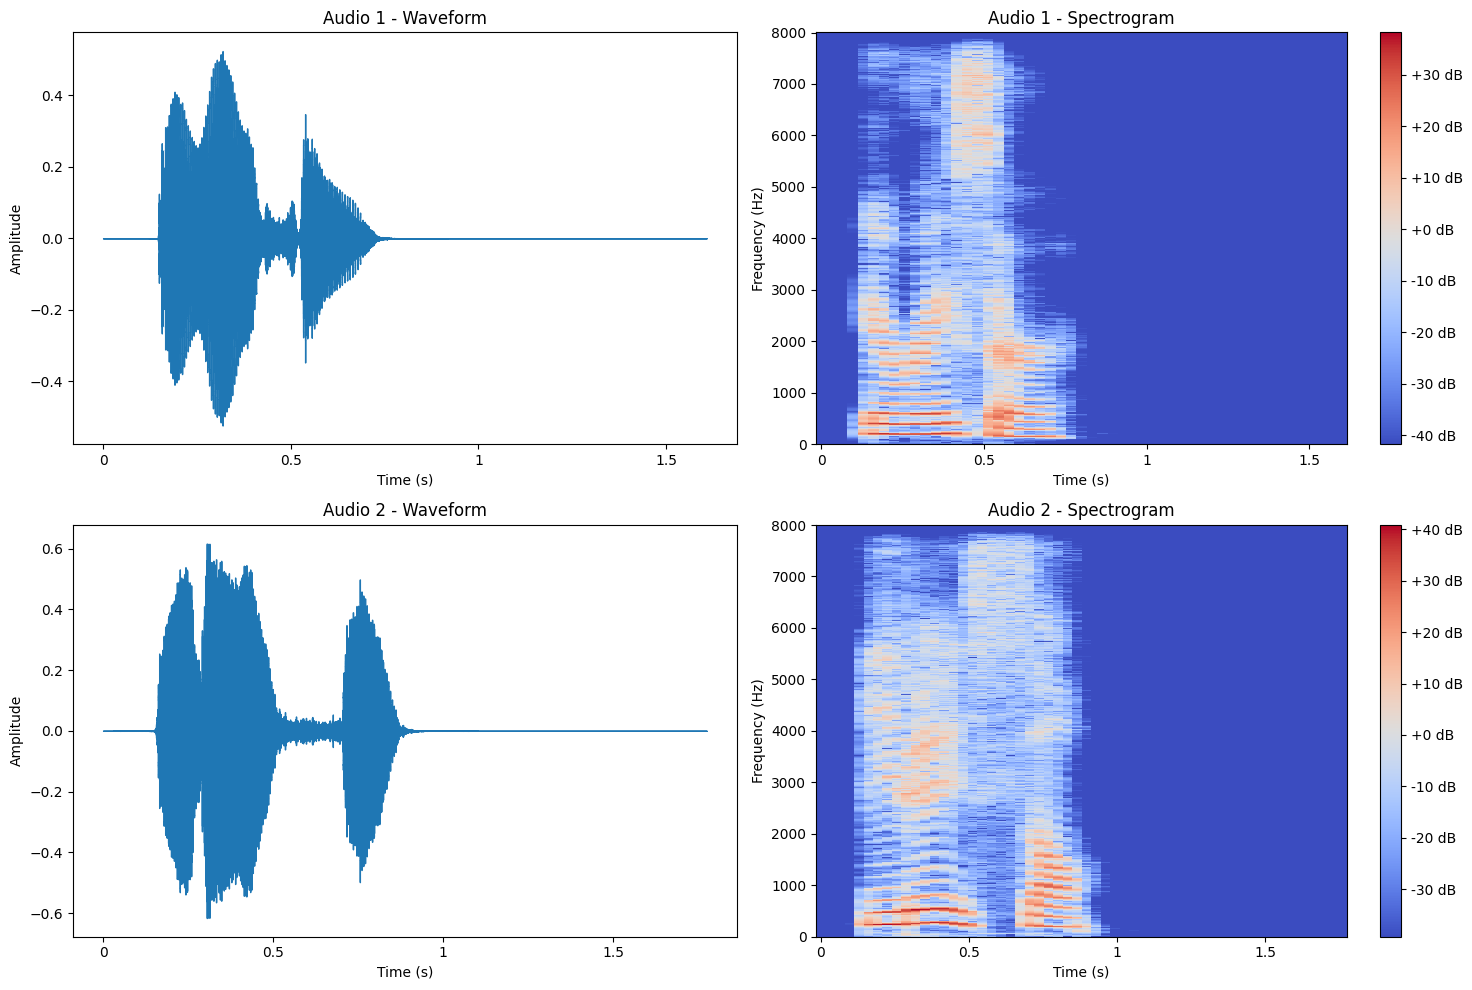

In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_waveform_and_spectrogram(file_path, ax_waveform, ax_spectrogram, title):
    # 음성 파일 로드
    audio, sr = librosa.load(file_path, sr=16000)
    
    # 파형 그리기
    librosa.display.waveshow(audio, sr=sr, ax=ax_waveform)
    ax_waveform.set_title(f"{title} - Waveform")
    ax_waveform.set_xlabel("Time (s)")
    ax_waveform.set_ylabel("Amplitude")
    
    # 스펙트로그램 그리기
    S = librosa.stft(audio)
    S_db = librosa.amplitude_to_db(abs(S))
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz", ax=ax_spectrogram)
    ax_spectrogram.set_title(f"{title} - Spectrogram")
    ax_spectrogram.set_xlabel("Time (s)")
    ax_spectrogram.set_ylabel("Frequency (Hz)")
    plt.colorbar(img, ax=ax_spectrogram, format="%+2.0f dB")

# 비교할 두 개의 파일 경로
file_path_1 = "eraser_a.wav"
file_path_2 = "eraser.wav"

# 그래프 생성
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 첫 번째 파일 시각화
plot_waveform_and_spectrogram(file_path_1, axs[0, 0], axs[0, 1], "Audio 1")

# 두 번째 파일 시각화
plot_waveform_and_spectrogram(file_path_2, axs[1, 0], axs[1, 1], "Audio 2")

plt.tight_layout()
plt.show()


In [25]:
import librosa
import numpy as np
import soundfile as sf

def random_augmentation(audio, sr):
    # 오디오가 mono인지 확인하고 변환
    if len(audio.shape) > 1:
        audio = librosa.to_mono(audio)

    # 랜덤 속도 조정 (0.9배 ~ 1.1배)
    speed_change = np.random.uniform(0.9, 1.1)
    audio = librosa.effects.time_stretch(audio, speed_change)

    # 랜덤 피치 조정 (-2 ~ 2 반음)
    pitch_change = np.random.uniform(-2, 2)
    audio = librosa.effects.pitch_shift(audio, sr, n_steps=pitch_change)

    # 랜덤 노이즈 추가 (0 ~ 0.005 크기)
    noise = np.random.normal(0, 0.005, audio.shape)
    audio = audio + noise
    
    return audio

# A와 B 파일 로드
audio_a, sr_a = librosa.load("eraser_a.wav", sr=16000)  # 원어민 음성 파일
audio_b, sr_b = librosa.load("eraser.wav", sr=16000)  # 어린 아이 음성 파일

# B 파일에 랜덤 조정 적용
augmented_audio_b = random_augmentation(audio_b, sr_b)
sf.write("audio_b_augmented.wav", augmented_audio_b, sr_b)

# 진폭 오차 계산 함수
def calculate_amplitude_error(audio_1, audio_2):
    min_length = min(len(audio_1), len(audio_2))
    audio_1 = audio_1[:min_length]
    audio_2 = audio_2[:min_length]
    
    amplitude_difference = audio_1 - audio_2
    mean_absolute_error = np.mean(np.abs(amplitude_difference))
    rms_error = np.sqrt(np.mean(amplitude_difference ** 2))
    
    return mean_absolute_error, rms_error

# 원어민 음성과 변형된 아이 음성 비교
mean_error, rms_error = calculate_amplitude_error(audio_a, augmented_audio_b)
print(f"Mean Absolute Error: {mean_error}")
print(f"RMS Error: {rms_error}")


TypeError: time_stretch() takes 1 positional argument but 2 were given